# KSSD2025 All 4 Models 5-Fold CV (10 Epochs)
Paper: "KSSD2025: A New Annotated Dataset for Automatic Kidney Stone
Segmentation and Evaluation With Modified U-Net Based Deep Learning Models"

Models: Modified U-Net, U-Net++, U-Net3+, TransU-Net

## 1. Setup

In [1]:
import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import KFold
from PIL import Image
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
for gpu in tf.config.list_physical_devices("GPU"):
    print(" ", gpu)

TensorFlow: 2.20.0
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


## 2. GPU Configuration

In [2]:
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

if len(gpus) >= 2:
    strategy = tf.distribute.MirroredStrategy(["/GPU:0", "/GPU:1"])
else:
    strategy = tf.distribute.get_strategy()

print("Replicas:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Replicas: 2


I0000 00:00:1786955523.657012     163 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786955523.659279     163 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 3. Hyperparameters

In [3]:
EPOCHS = 10
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
N_FOLDS = 5
SEED = 42
FILTERS = [16, 32, 64, 128, 256]

## 4. Load Dataset

In [4]:
DATA_DIR = "/kaggle/input/datasets/murillobouzon/kssd2025-kidney-stone-segmentation-dataset/data"
IMG_DIR = os.path.join(DATA_DIR, "image")
LABEL_DIR = os.path.join(DATA_DIR, "label")

common = sorted(set(os.listdir(IMG_DIR)) & set(os.listdir(LABEL_DIR)))
print(f"Matched pairs: {len(common)}")

X_list, Y_list = [], []
for fname in common:
    img = np.asarray(Image.open(os.path.join(IMG_DIR, fname)).convert("L"), dtype=np.float32) / 255.0
    msk = (np.asarray(Image.open(os.path.join(LABEL_DIR, fname)).convert("L"), dtype=np.float32) > 0).astype(np.float32)
    X_list.append(img[..., np.newaxis])
    Y_list.append(msk[..., np.newaxis])

X = np.array(X_list, dtype=np.float32)
Y = np.array(Y_list, dtype=np.float32)
del X_list, Y_list
gc.collect()

print(f"X: {X.shape}, Y: {Y.shape}")

Matched pairs: 838
X: (838, 512, 512, 1), Y: (838, 512, 512, 1)


## 5. Dice Loss & Metrics

In [6]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    return 1.0 - (2.0 * intersection + smooth) / (denom + smooth)

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    return tf.reduce_mean((2.0 * intersection + smooth) / (denom + smooth))

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3]) - intersection
    return tf.reduce_mean((intersection + smooth) / (union + smooth))

def precision_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred_bin = tf.cast(y_pred >= 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_bin, axis=[1, 2, 3])
    pp = tf.reduce_sum(y_pred_bin, axis=[1, 2, 3])
    return tf.reduce_mean((tp + smooth) / (pp + smooth))

def recall_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred_bin = tf.cast(y_pred >= 0.5, tf.float32)
    tp = tf.reduce_sum(y_true * y_pred_bin, axis=[1, 2, 3])
    ap = tf.reduce_sum(y_true, axis=[1, 2, 3])
    return tf.reduce_mean((tp + smooth) / (ap + smooth))

## 6. Model Definitions

### 6a. Modified U-Net (custom)

In [ ]:
# def conv_block(x, filters, dropout_rate=0.0):
#     x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)
#     if dropout_rate > 0:
#         x = layers.Dropout(dropout_rate)(x)
#     x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)
#     return x

# def build_modified_unet(input_shape=(512, 512, 1)):
#     inputs = layers.Input(shape=input_shape)

#     e1 = conv_block(inputs, 16, 0.1);  p1 = layers.MaxPooling2D(2)(e1)
#     e2 = conv_block(p1, 32, 0.2);      p2 = layers.MaxPooling2D(2)(e2)
#     e3 = conv_block(p2, 64, 0.3);      p3 = layers.MaxPooling2D(2)(e3)
#     e4 = conv_block(p3, 128, 0.3);     p4 = layers.MaxPooling2D(2)(e4)

#     b = conv_block(p4, 256, 0.3)

#     u4 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(b)
#     u4 = layers.Concatenate()([u4, e4]); u4 = conv_block(u4, 128)

#     u3 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(u4)
#     u3 = layers.Concatenate()([u3, e3]); u3 = conv_block(u3, 64)

#     u2 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(u3)
#     u2 = layers.Concatenate()([u2, e2]); u2 = conv_block(u2, 32)

#     u1 = layers.Conv2DTranspose(16, 2, strides=2, padding="same")(u2)
#     u1 = layers.Concatenate()([u1, e1]); u1 = conv_block(u1, 16)

#     outputs = layers.Conv2D(1, 1, activation="sigmoid")(u1)
#     return Model(inputs, outputs, name="Modified_UNet")

### 6b. U-Net++, U-Net3+, TransU-Net (keras-unet-collection)

In [7]:
!pip install -q keras-unet-collection
from keras_unet_collection import models as kuc

def build_unetpp(input_shape=(512, 512, 1)):
    return kuc.unet_plus_2d(
        input_size=input_shape, filter_num=FILTERS, n_labels=1,
        stack_num_down=2, stack_num_up=2,
        activation="ReLU", output_activation="Sigmoid",
        batch_norm=True, pool=True, unpool=True,
        deep_supervision=False, backbone=None, name="UNetPP",
    )

def build_unet3plus(input_shape=(512, 512, 1)):
    return kuc.unet_3plus_2d(
        input_size=input_shape, n_labels=1,
        filter_num_down=FILTERS,
        filter_num_skip=[22, 22, 22, 22], filter_num_aggregate=110,
        stack_num_down=2, stack_num_up=2,
        activation="ReLU", output_activation="Sigmoid",
        batch_norm=True, pool=True, unpool=True,
        deep_supervision=False, backbone=None, name="UNet3Plus",
    )

# def build_transunet(input_shape=(512, 512, 1)):
#     return kuc.transunet_2d(
#         input_size=input_shape, filter_num=FILTERS, n_labels=1,
#         stack_num_down=2, stack_num_up=2,
#         embed_dim=192, num_mlp=384, num_heads=4, num_transformer=3,
#         activation="ReLU", mlp_activation="GELU", output_activation="Sigmoid",
#         batch_norm=True, pool=True, unpool=True,
#         backbone=None, name="TransUNet",
#     )

MODEL_BUILDERS = {
    # "Modified_UNet": build_modified_unet,
    "UNetPP": build_unetpp,
    "UNet3Plus": build_unet3plus,
    # "TransUNet": build_transunet,
}

print("All 4 model builders ready")

All 4 model builders ready


### 6c. Verify all models

In [8]:
for name, builder in MODEL_BUILDERS.items():
    with strategy.scope():
        m = builder()
    print(f"{name:15s} {m.count_params():>10,} params  |  out={m.output_shape}")
    del m
    tf.keras.backend.clear_session()
    gc.collect()

UNetPP          â€”  1,967,713 params  |  out=(None, 512, 512, 1)
UNet3Plus       â€”  2,374,583 params  |  out=(None, 512, 512, 1)


## 7. Create Folds

In [9]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(kf.split(X))
for i, (tr, va) in enumerate(folds, 1):
    print(f"Fold {i}: train={len(tr)}, val={len(va)}")

Fold 1: train=670, val=168
Fold 2: train=670, val=168
Fold 3: train=670, val=168
Fold 4: train=671, val=167
Fold 5: train=671, val=167


## 8. Train All Models One at a Time

Each model trains all 5 folds, then the next model starts.
Change `MODELS_TO_TRAIN` if you want to skip some.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE
MODELS_TO_TRAIN = ["UNetPP", "UNet3Plus"]
all_results = {}

for model_name in MODELS_TO_TRAIN:
    print(f"\n{'#'*60}")
    print(f"# MODEL: {model_name}")
    print(f"{'#'*60}")

    builder = MODEL_BUILDERS[model_name]
    model_histories = {}

    for fold_idx, (train_idx, val_idx) in enumerate(folds, 1):
        print(f"\n--- {model_name} of Fold {fold_idx}/{N_FOLDS} ---")

        # Datasets
        train_ds = tf.data.Dataset.from_tensor_slices((X[train_idx], Y[train_idx]))
        train_ds = train_ds.shuffle(len(train_idx), reshuffle_each_iteration=True)
        train_ds = train_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(AUTOTUNE)

        val_ds = tf.data.Dataset.from_tensor_slices((X[val_idx], Y[val_idx]))
        val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

        # Build & compile
        with strategy.scope():
            model = builder()
            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                loss=dice_loss,
                metrics=[dice_coef, iou_metric, precision_metric, recall_metric],
            )

        # Train
        history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
        model_histories[fold_idx] = history.history

        # Save
        save_path = f"/kaggle/working/{model_name}_fold{fold_idx}.keras"
        model.save(save_path)
        print(f"Saved: {save_path}")

        del model, train_ds, val_ds
        tf.keras.backend.clear_session()
        gc.collect()

    all_results[model_name] = model_histories
    print(f"\n>>> {model_name} â€” ALL 5 FOLDS DONE <<<")


############################################################
# MODEL: UNetPP
############################################################

--- UNetPP â€” Fold 1/5 ---
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CP

## 9. Results Summary of UNet++ & UNet3+

In [11]:
print(f"\n{'='*70}")
print("5-FOLD CV RESULTS of UNet++ & UNet3+")
print(f"{'='*70}\n")

summary_table = {}

for model_name in MODELS_TO_TRAIN:
    histories = all_results[model_name]
    dice_scores, iou_scores, prec_scores, rec_scores = [], [], [], []

    for fold_idx in range(1, N_FOLDS + 1):
        h = histories[fold_idx]
        dice_scores.append(max(h["val_dice_coef"]))
        iou_scores.append(max(h["val_iou_metric"]))
        prec_scores.append(max(h["val_precision_metric"]))
        rec_scores.append(max(h["val_recall_metric"]))

    summary_table[model_name] = {
        "Dice": (np.mean(dice_scores), np.std(dice_scores)),
        "IoU": (np.mean(iou_scores), np.std(iou_scores)),
        "Precision": (np.mean(prec_scores), np.std(prec_scores)),
        "Recall": (np.mean(rec_scores), np.std(rec_scores)),
    }

    print(f"{model_name}:")
    for fold_idx in range(1, N_FOLDS + 1):
        h = histories[fold_idx]
        print(f"  Fold {fold_idx}: Dice={max(h['val_dice_coef']):.4f}  IoU={max(h['val_iou_metric']):.4f}")
    print(f"  Mean: Dice={np.mean(dice_scores):.4f}Â±{np.std(dice_scores):.4f}  IoU={np.mean(iou_scores):.4f}Â±{np.std(iou_scores):.4f}")
    print()

# Final comparison table
print(f"\n{'='*70}")
print(f"{'Model':15s} {'Dice':>14s} {'IoU':>14s} {'Precision':>14s} {'Recall':>14s}")
print(f"{'='*70}")
for model_name, metrics in summary_table.items():
    d = metrics["Dice"]
    i = metrics["IoU"]
    p = metrics["Precision"]
    r = metrics["Recall"]
    print(f"{model_name:15s} {d[0]:.4f}Â±{d[1]:.4f} {i[0]:.4f}Â±{i[1]:.4f} {p[0]:.4f}Â±{p[1]:.4f} {r[0]:.4f}Â±{r[1]:.4f}")


5-FOLD CV RESULTS â€” ALL MODELS

UNetPP:
  Fold 1: Dice=0.5720  IoU=0.4196
  Fold 2: Dice=0.5342  IoU=0.3831
  Fold 3: Dice=0.5207  IoU=0.3726
  Fold 4: Dice=0.5319  IoU=0.3784
  Fold 5: Dice=0.5218  IoU=0.3677
  Mean: Dice=0.5361Â±0.0187  IoU=0.3843Â±0.0184

UNet3Plus:
  Fold 1: Dice=0.6113  IoU=0.4565
  Fold 2: Dice=0.5959  IoU=0.4402
  Fold 3: Dice=0.5671  IoU=0.4147
  Fold 4: Dice=0.5791  IoU=0.4238
  Fold 5: Dice=0.5920  IoU=0.4332
  Mean: Dice=0.5891Â±0.0150  IoU=0.4337Â±0.0143


Model                     Dice            IoU      Precision         Recall
UNetPP          0.5361Â±0.0187 0.3843Â±0.0184 0.7727Â±0.1200 0.9964Â±0.0027
UNet3Plus       0.5891Â±0.0150 0.4337Â±0.0143 1.0000Â±0.0000 0.6623Â±0.0417


## 10. Training Curves of All Models

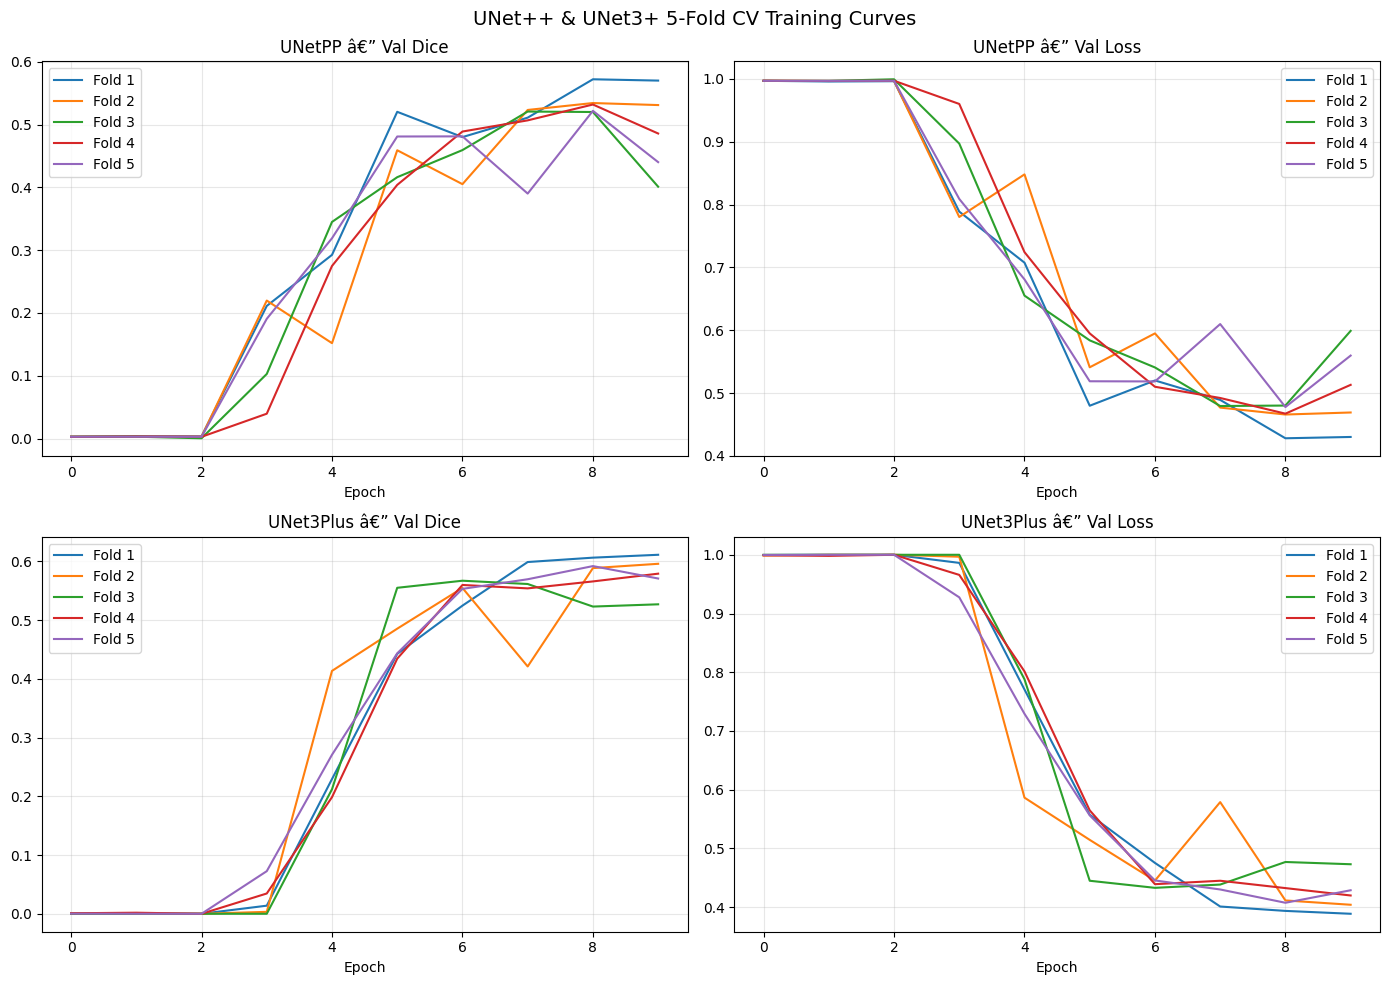

In [14]:
fig, axes = plt.subplots(len(MODELS_TO_TRAIN), 2, figsize=(14, 5 * len(MODELS_TO_TRAIN)))

for row, model_name in enumerate(MODELS_TO_TRAIN):
    histories = all_results[model_name]

    for fold_idx in range(1, N_FOLDS + 1):
        h = histories[fold_idx]
        axes[row, 0].plot(h["val_dice_coef"], label=f"Fold {fold_idx}")
        axes[row, 1].plot(h["val_loss"], label=f"Fold {fold_idx}")

    axes[row, 0].set_title(f"{model_name} â€” Val Dice")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].legend()
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].set_title(f"{model_name} Val Loss")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)

plt.suptitle("UNet++ & UNet3+ 5-Fold CV Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/all_models_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Sample Predictions of Best Fold of Each Model

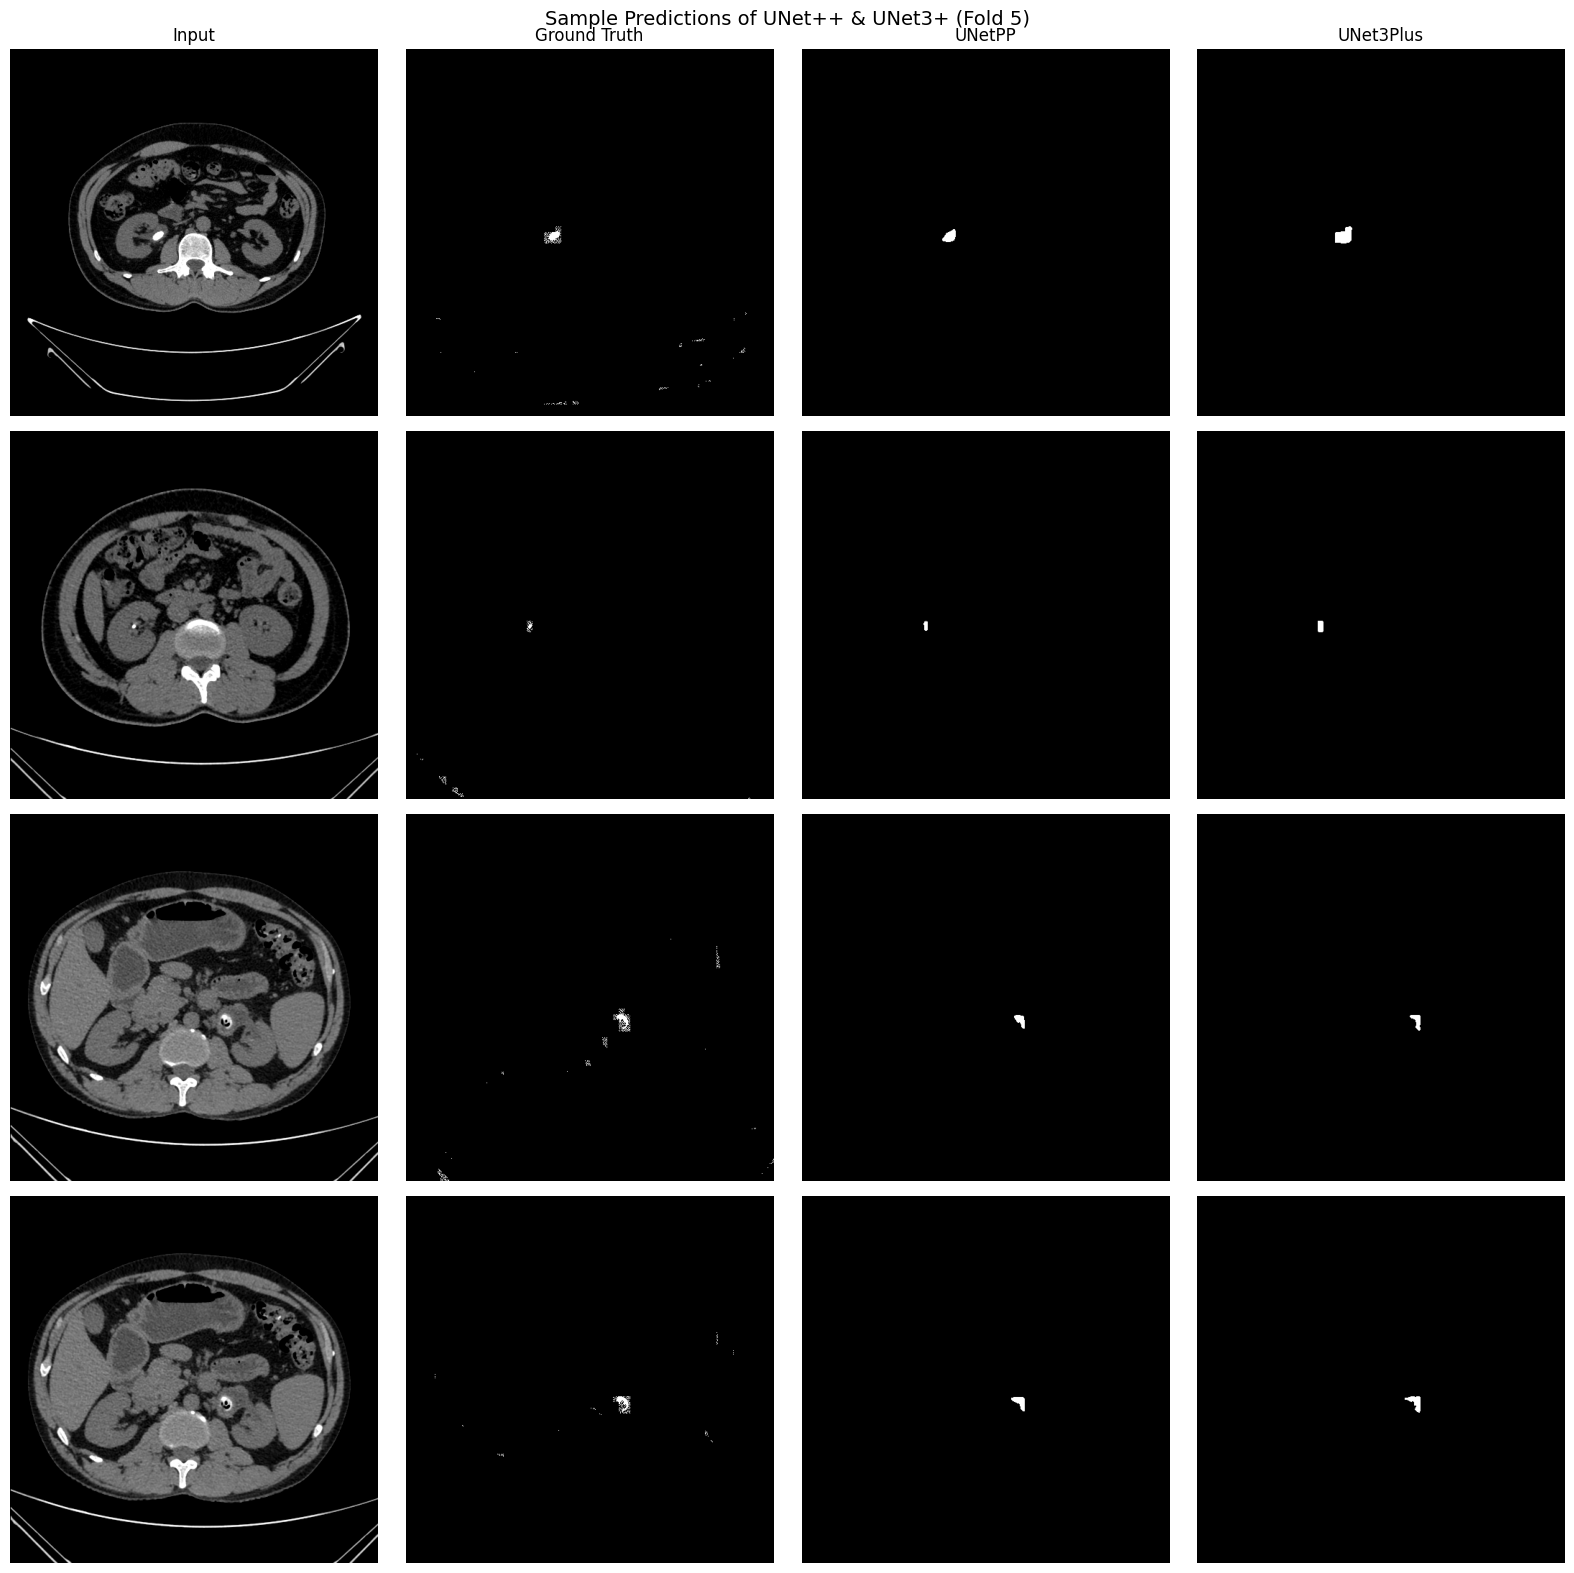

In [16]:
_, last_val_idx = folds[N_FOLDS - 1]
sample_indices = last_val_idx[:4]

fig, axes = plt.subplots(4, len(MODELS_TO_TRAIN) + 2, figsize=(4 * (len(MODELS_TO_TRAIN) + 2), 16))

for i, idx in enumerate(sample_indices):
    axes[i, 0].imshow(X[idx, ..., 0], cmap="gray")
    axes[i, 0].set_title("Input" if i == 0 else "")

    axes[i, 1].imshow(Y[idx, ..., 0], cmap="gray")
    axes[i, 1].set_title("Ground Truth" if i == 0 else "")

    for j, model_name in enumerate(MODELS_TO_TRAIN):
        model_path = f"/kaggle/working/{model_name}_fold{N_FOLDS}.keras"
        m = tf.keras.models.load_model(model_path, custom_objects={
            "dice_loss": dice_loss, "dice_coef": dice_coef,
            "iou_metric": iou_metric, "precision_metric": precision_metric,
            "recall_metric": recall_metric,
        })
        pred = m.predict(X[idx:idx+1], verbose=0)[0, ..., 0]
        axes[i, j + 2].imshow(pred > 0.5, cmap="gray")
        axes[i, j + 2].set_title(model_name if i == 0 else "")
        del m
        tf.keras.backend.clear_session()

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Sample Predictions of UNet++ & UNet3+ (Fold 5)", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/all_models_predictions.png", dpi=150, bbox_inches="tight")
plt.show()